In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import re
import os

In [47]:
df = pd.read_csv('Datasets/historic_park_data.csv', thousands=',')
df.fillna(0, inplace=True)
df["Date"] = pd.to_datetime(df["Year"].astype(str), format="%Y")

In [48]:
df.head()

,ParkName,UnitCode,ParkType,Region,State,Year,Total,Date
0,Acadia NP,ACAD,National Park,Northeast,ME,1919,64000,1919-01-01
1,Acadia NP,ACAD,National Park,Northeast,ME,1920,66500,1920-01-01
2,Acadia NP,ACAD,National Park,Northeast,ME,1921,69836,1921-01-01
3,Acadia NP,ACAD,National Park,Northeast,ME,1922,73779,1922-01-01
4,Acadia NP,ACAD,National Park,Northeast,ME,1923,64200,1923-01-01


In [49]:
park_list = df['ParkName'].unique()

R2 = {}

/var/folders/ln/ccc333gd343_2blclyk9w8wc0000gn/T/ipykernel_7997/4071490913.py:17: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



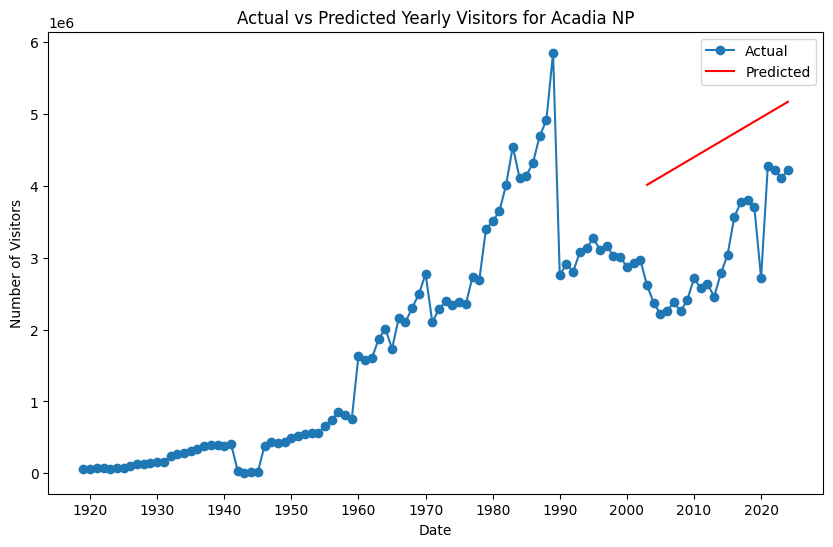

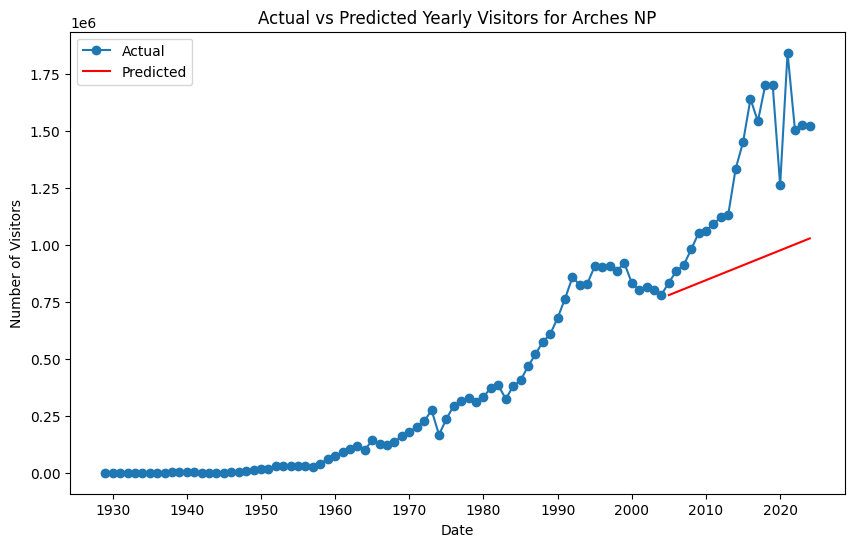

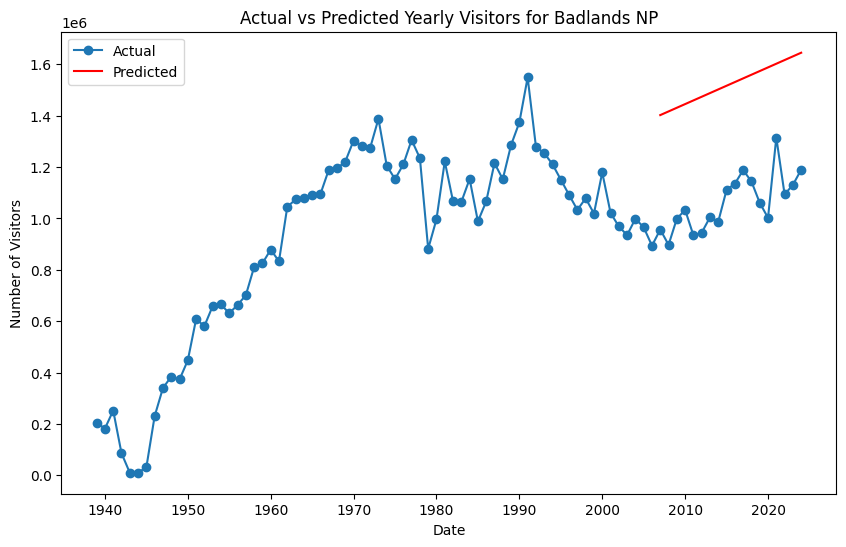

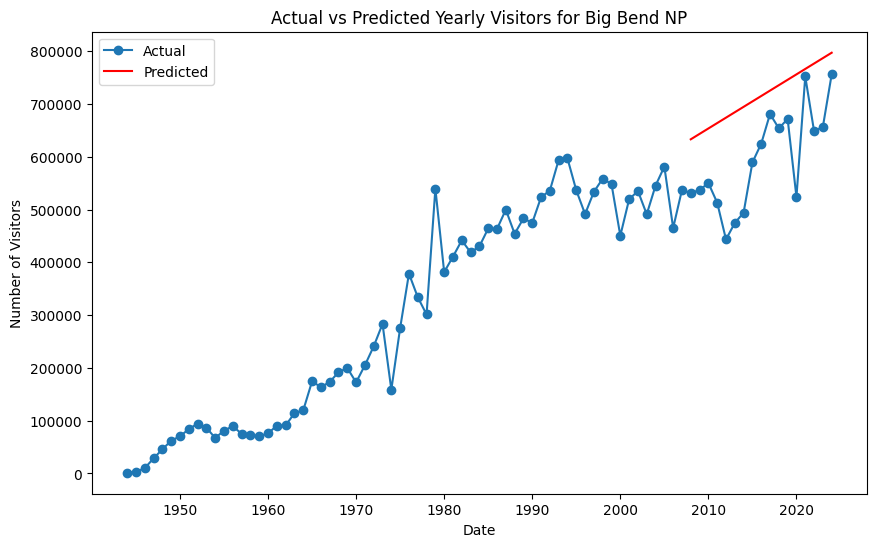

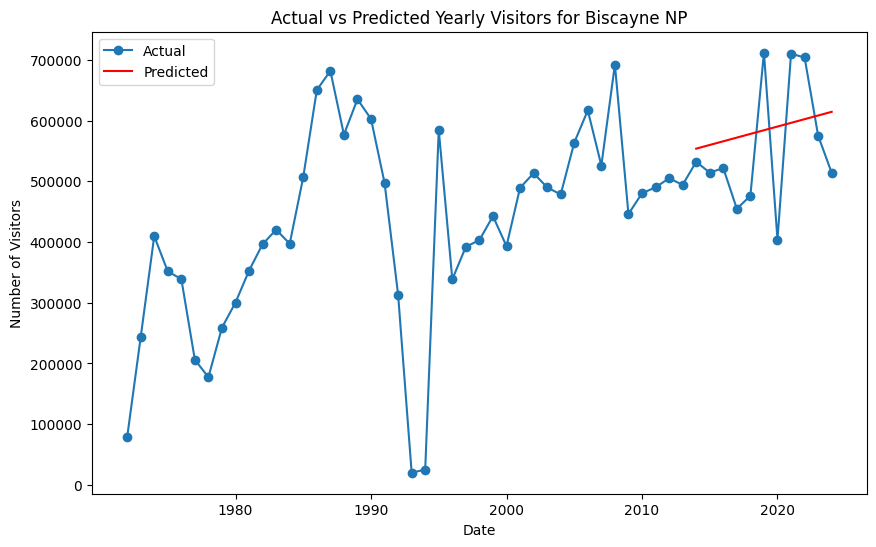

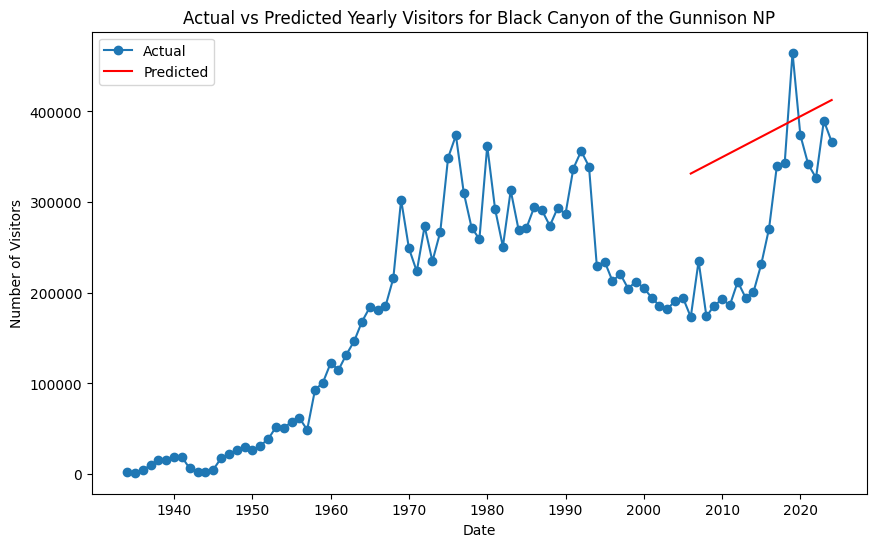

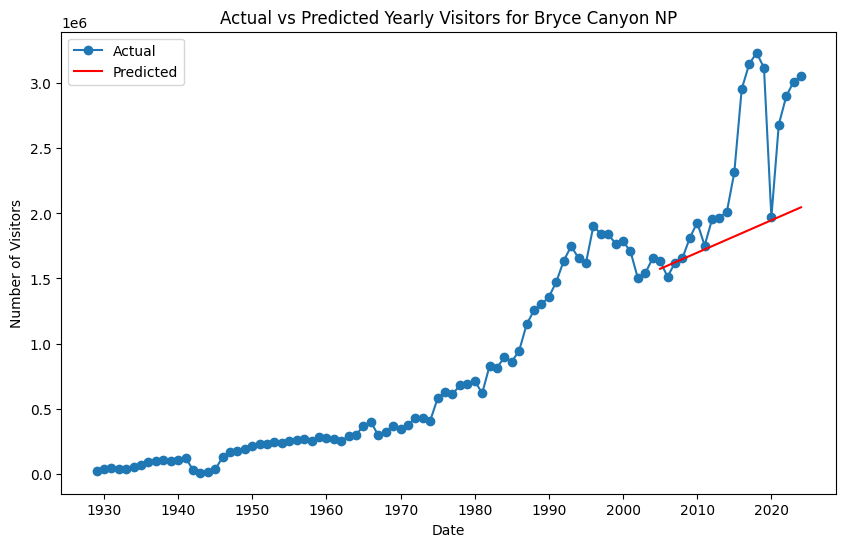

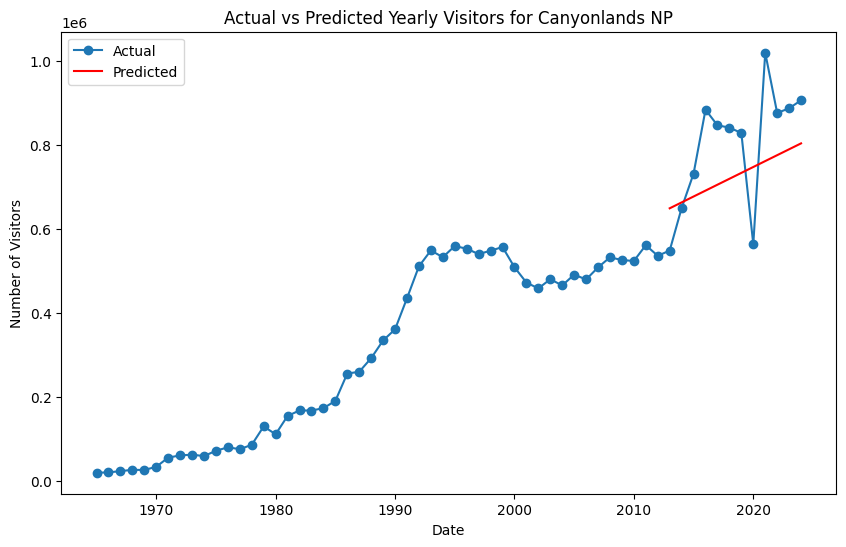

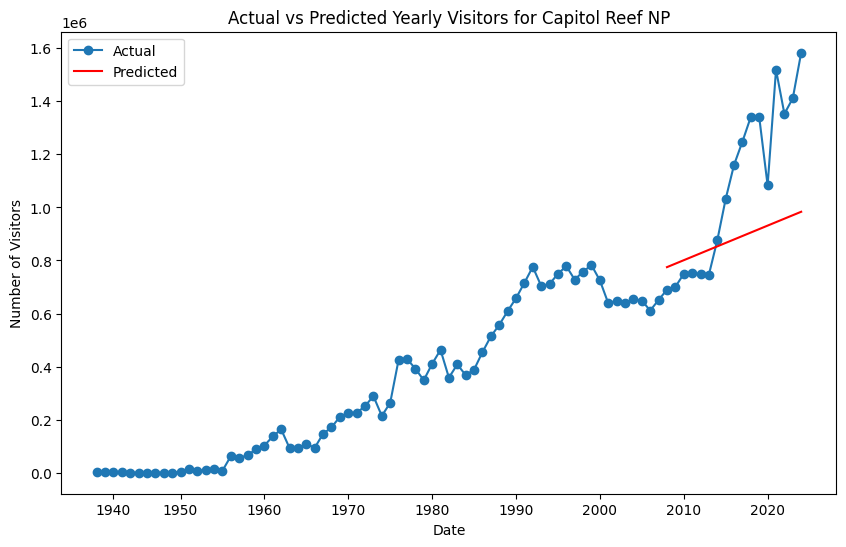

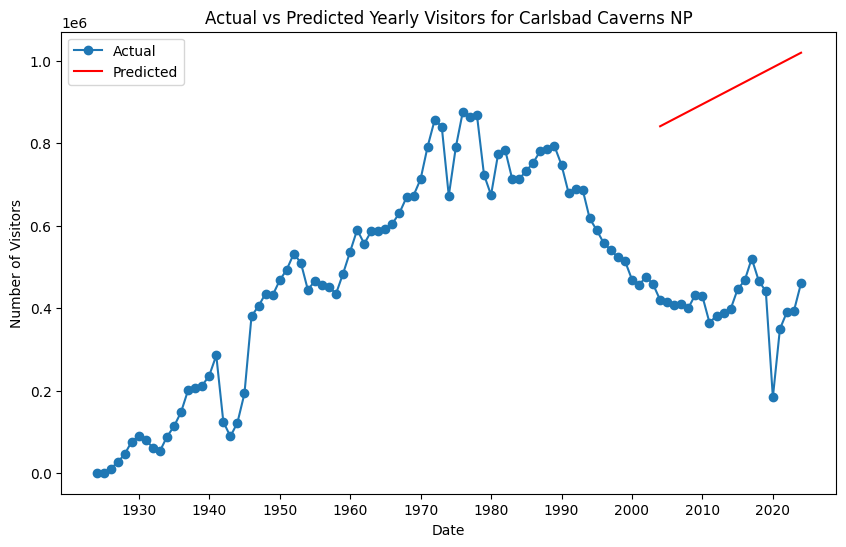

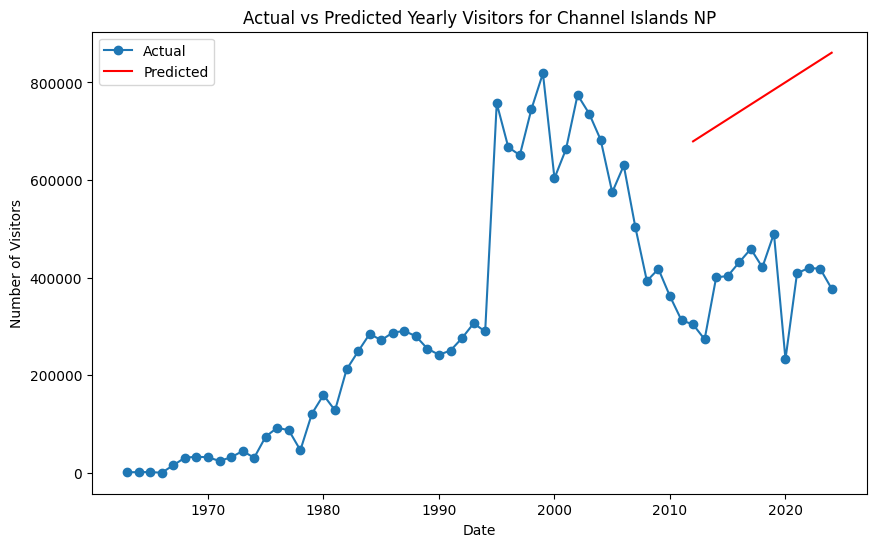

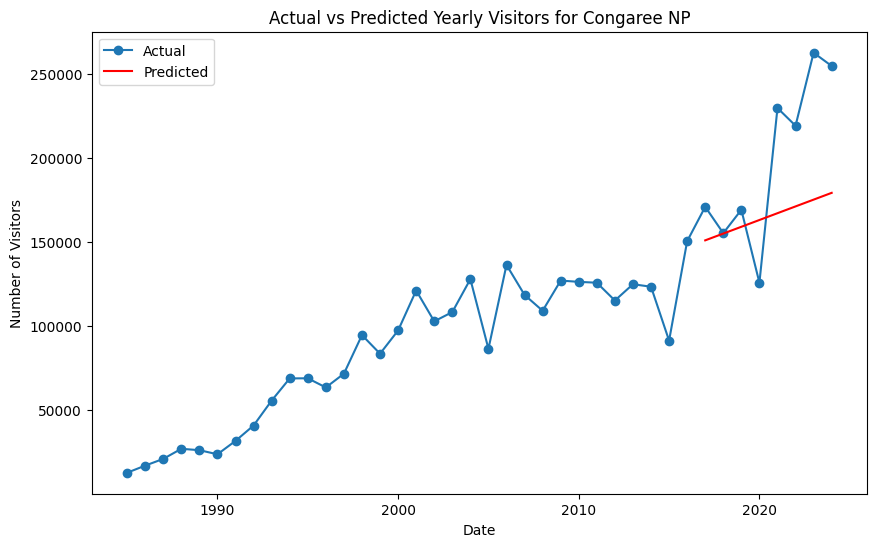

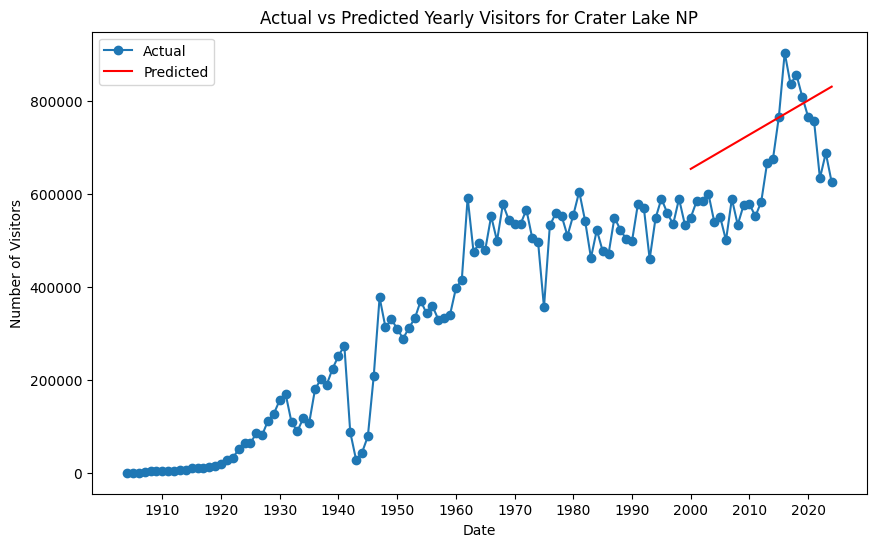

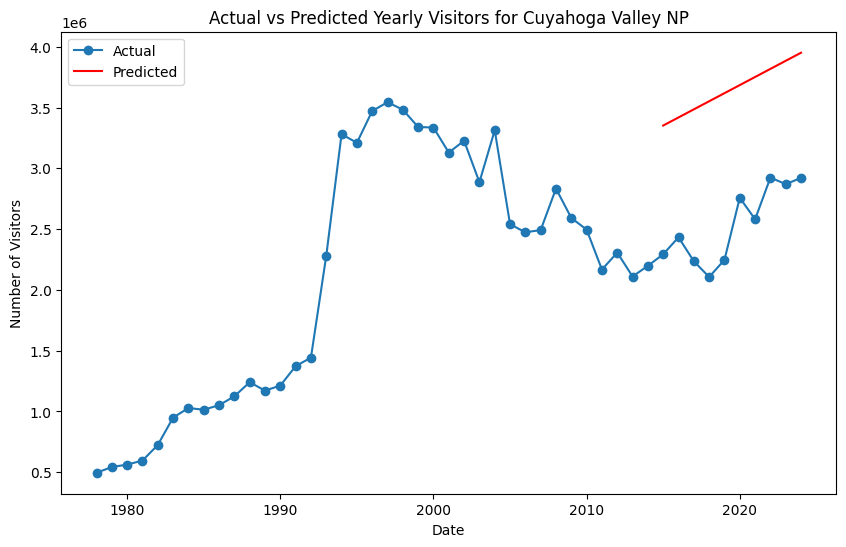

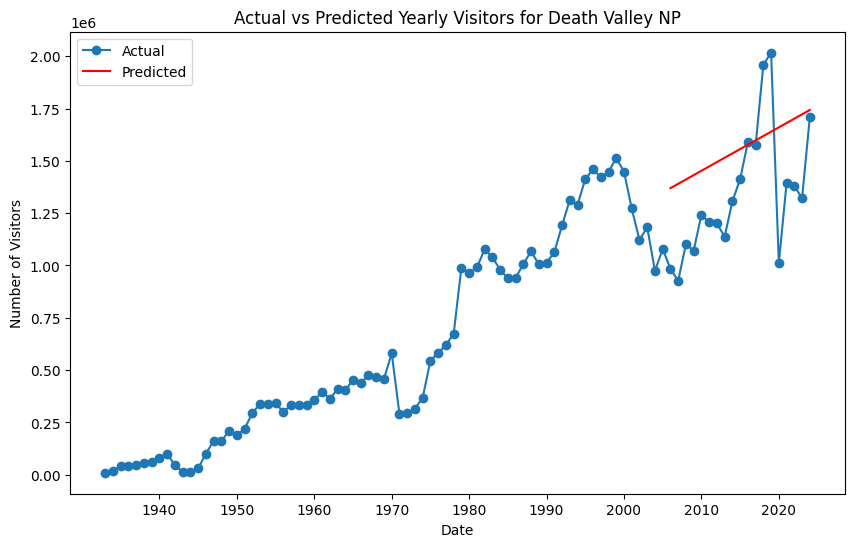

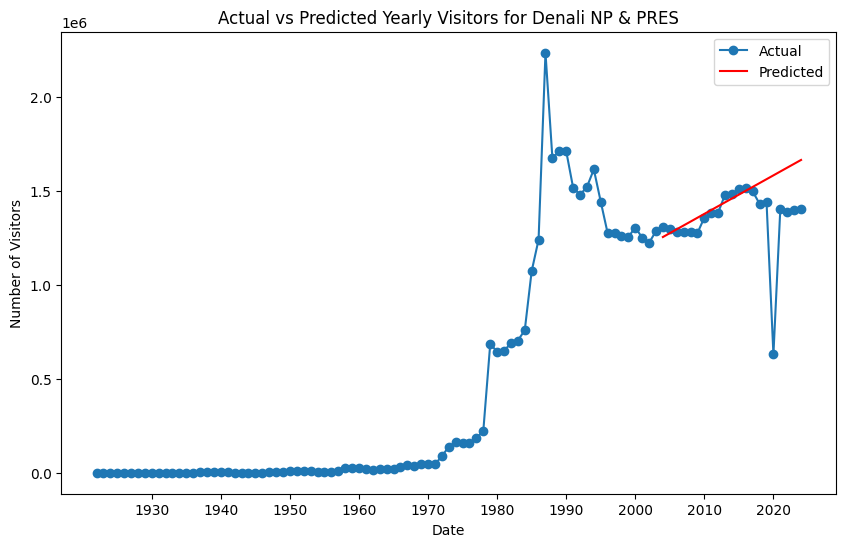

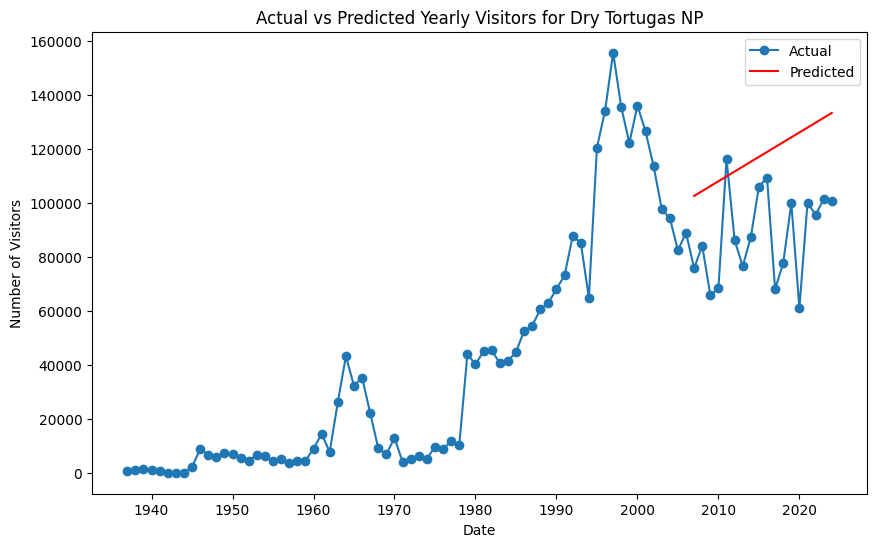

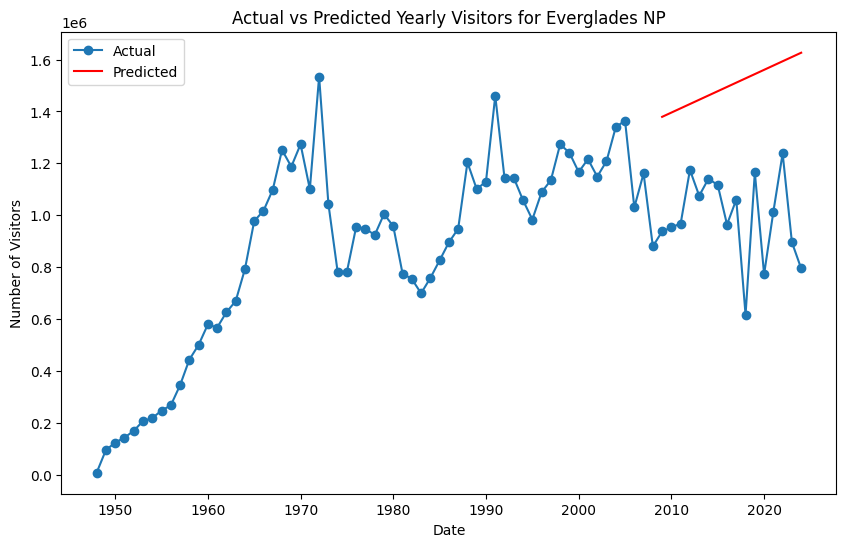

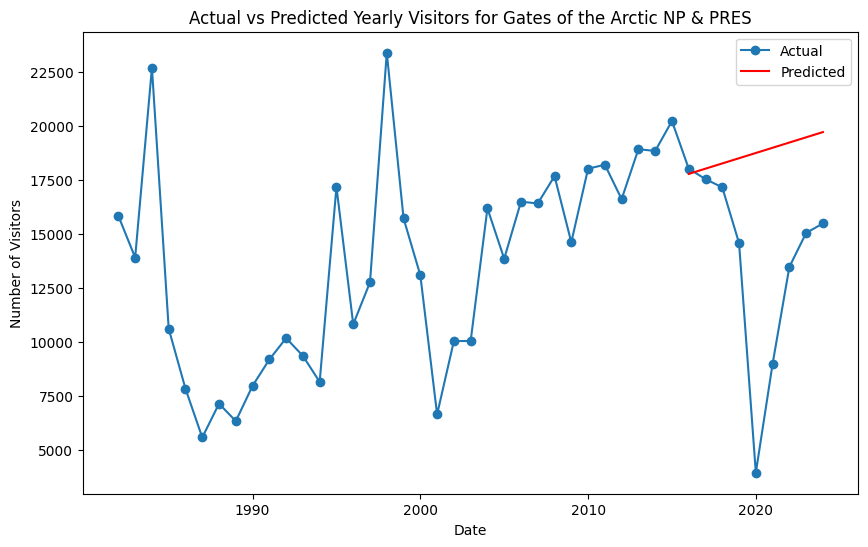

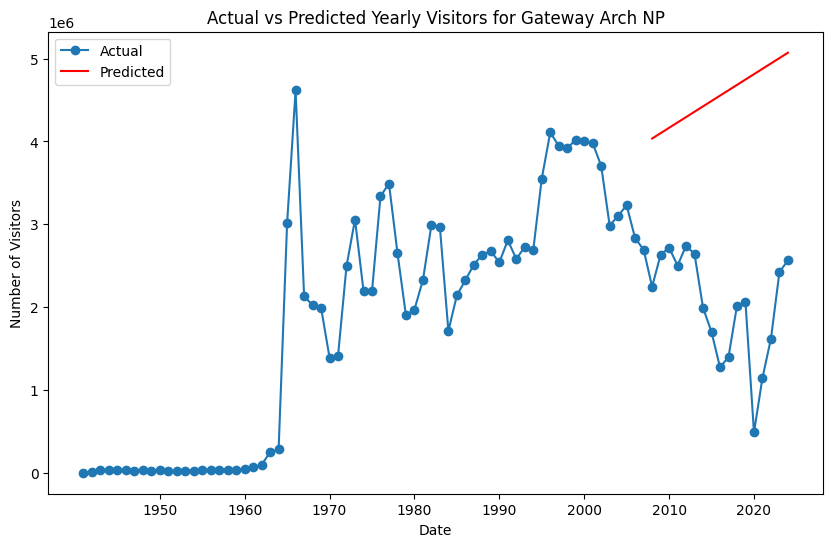

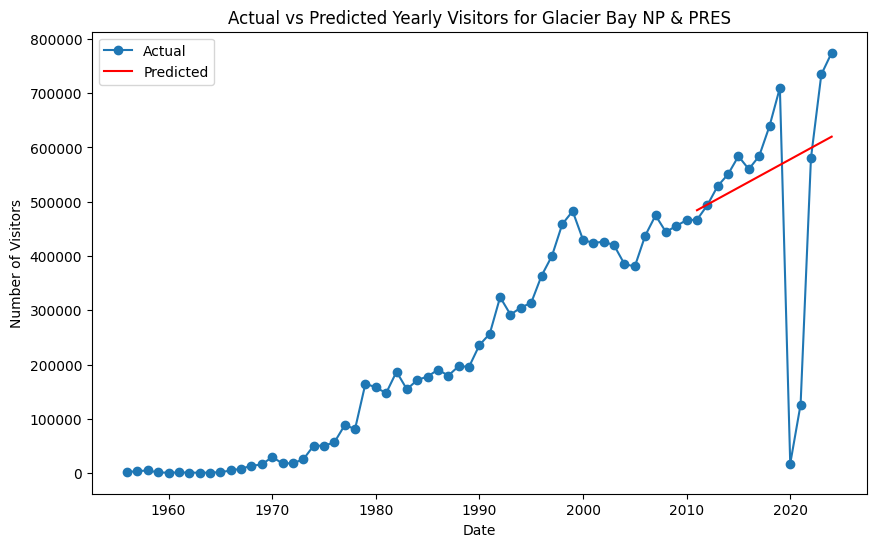

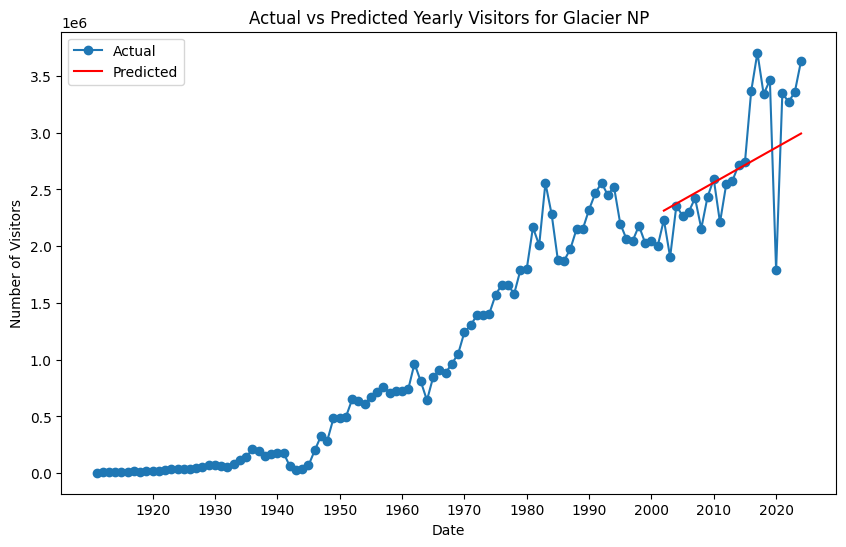

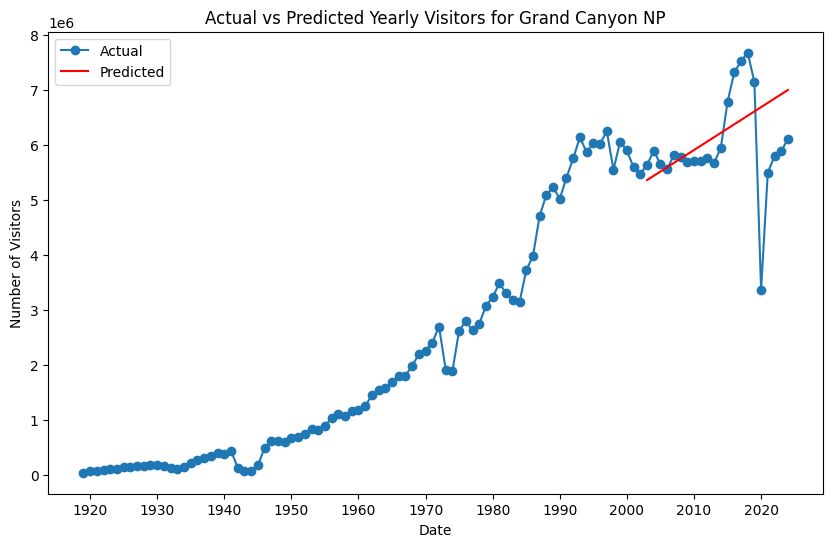

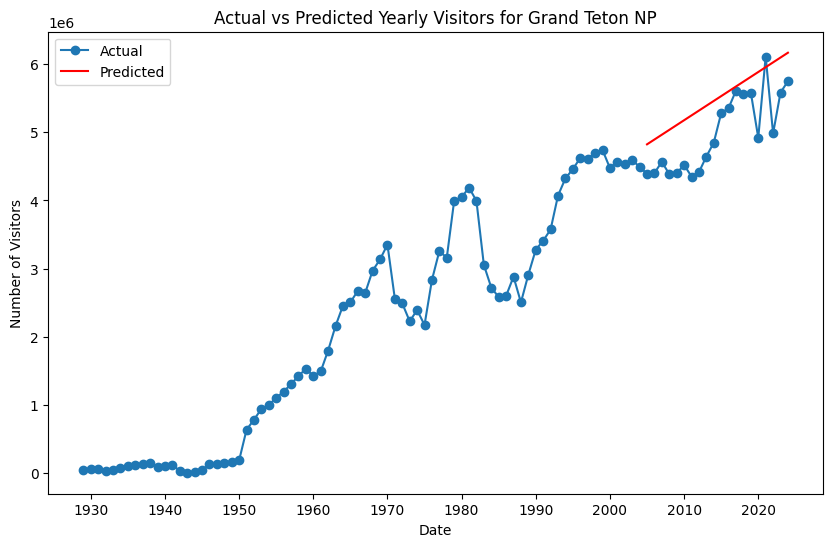

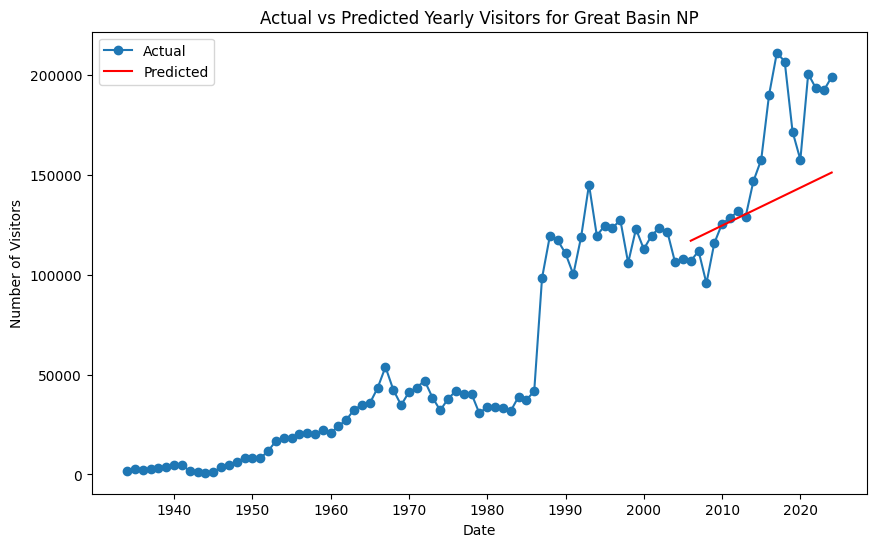

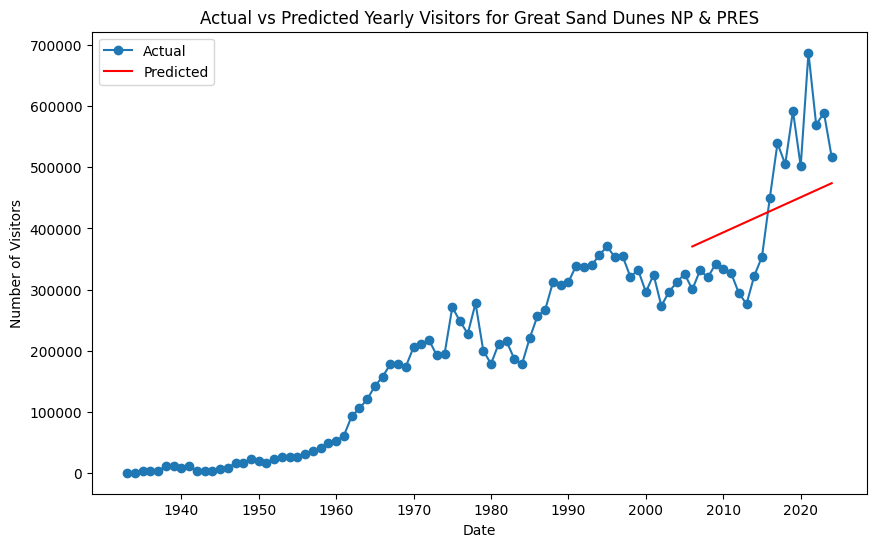

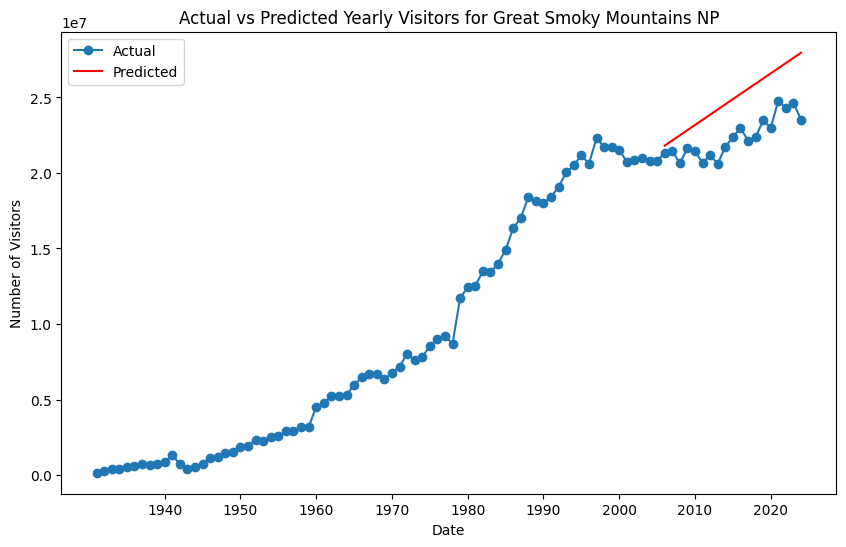

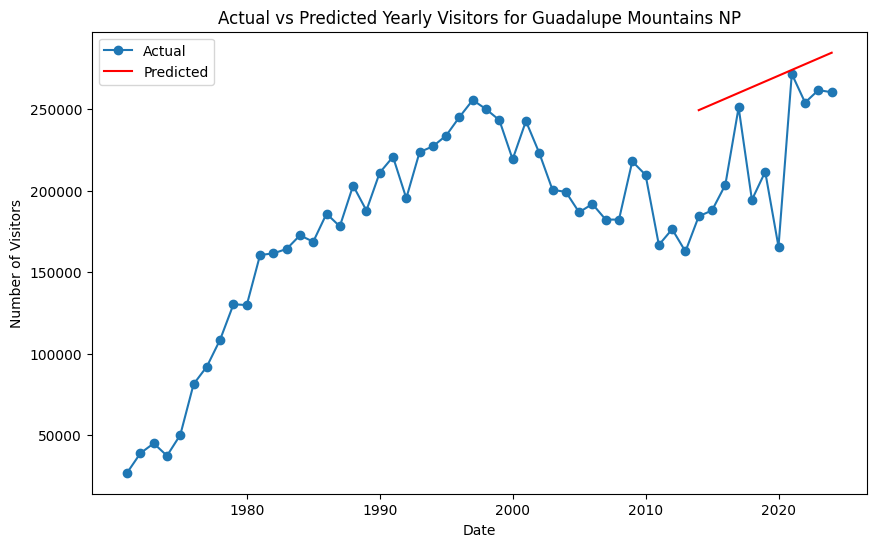

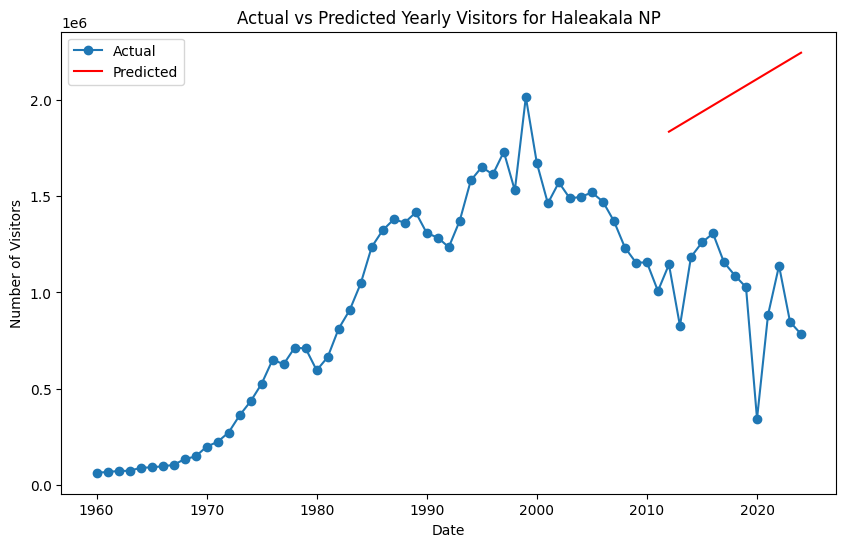

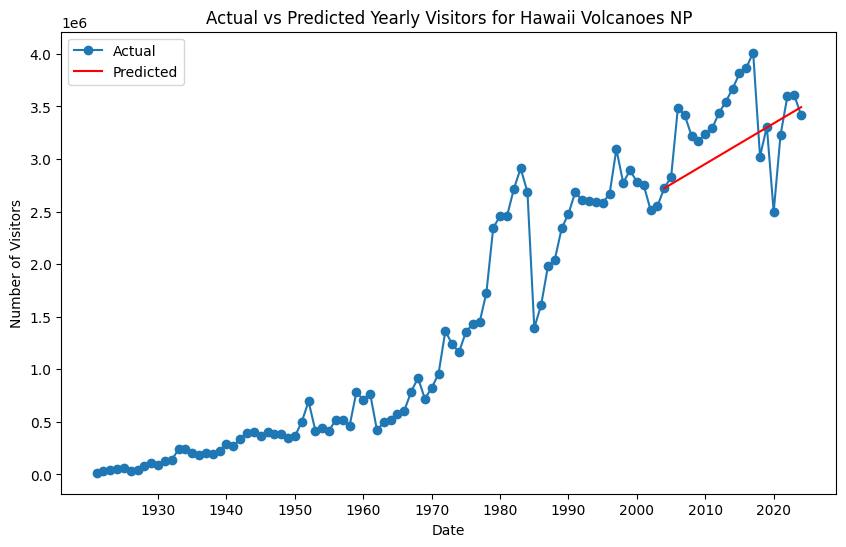

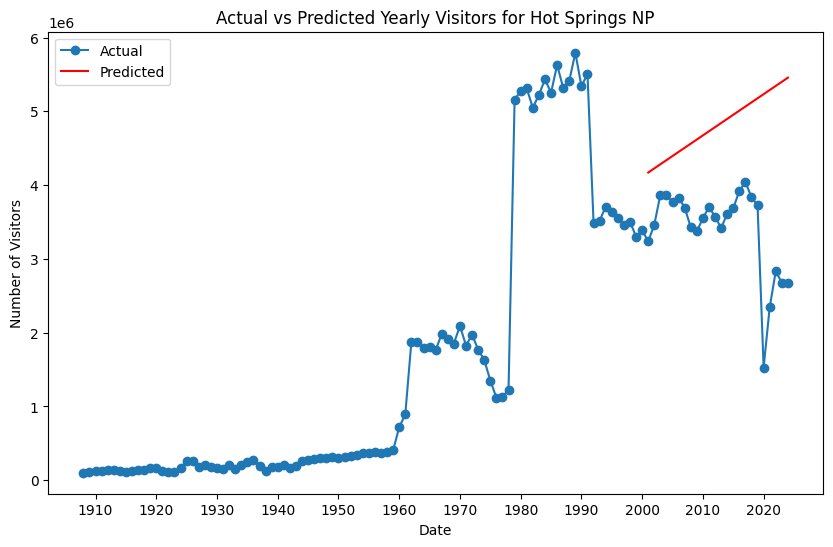

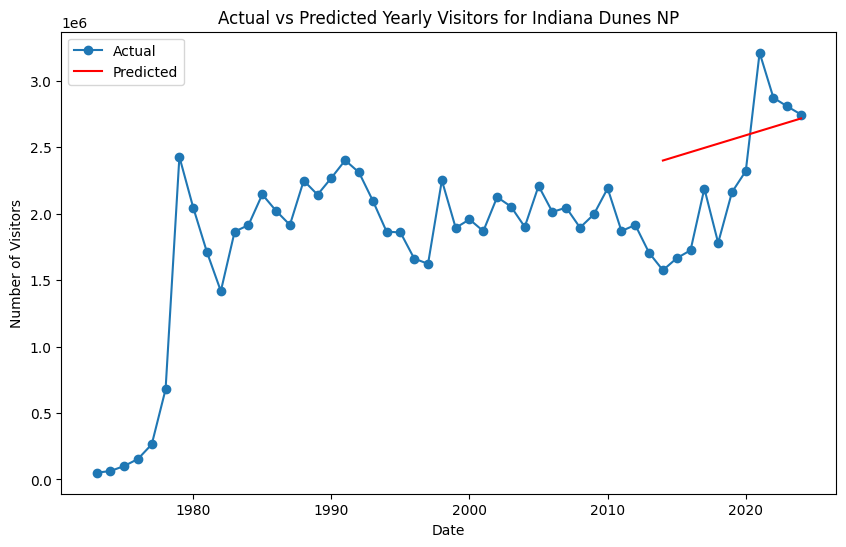

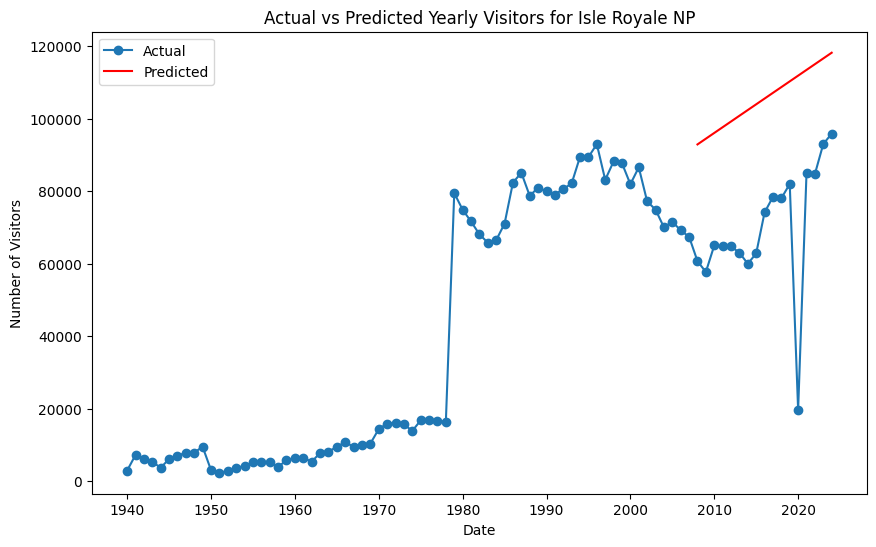

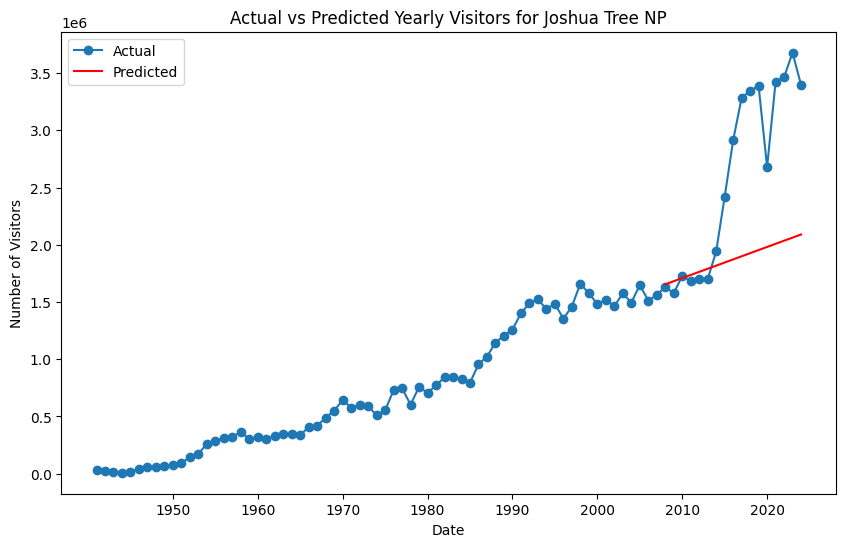

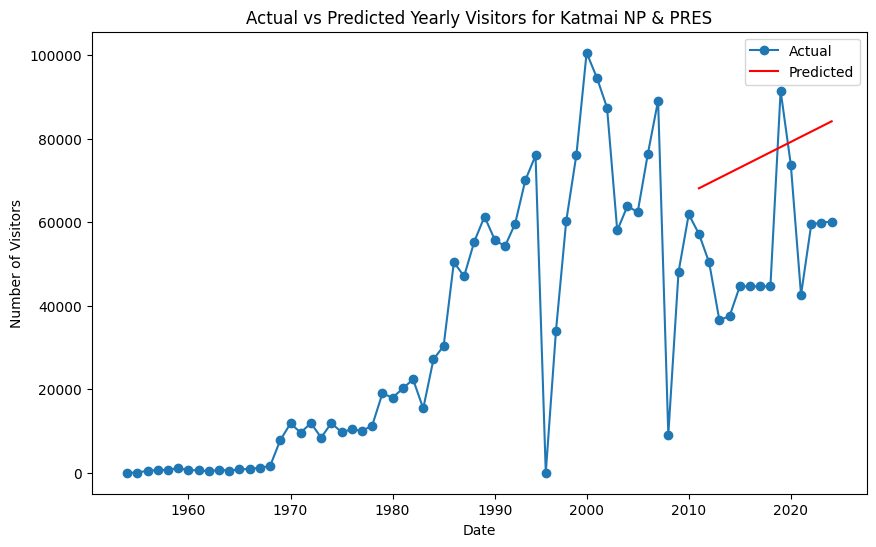

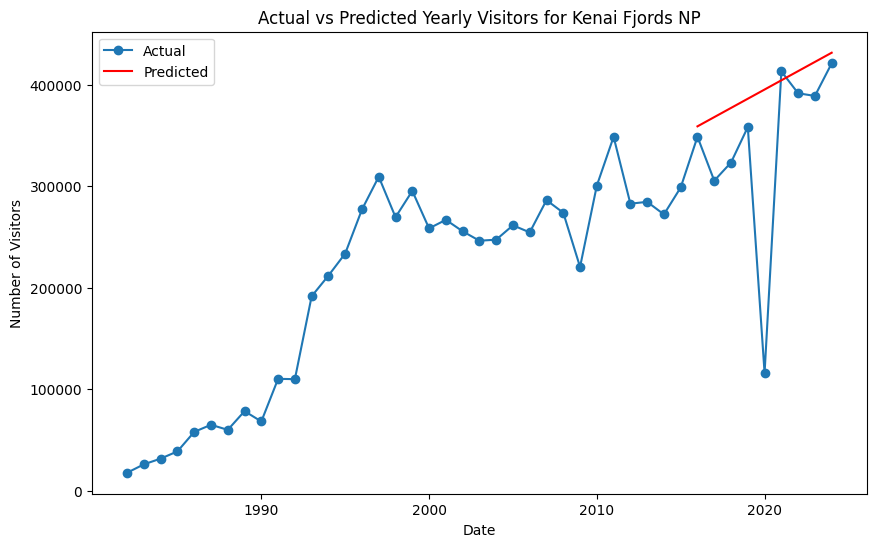

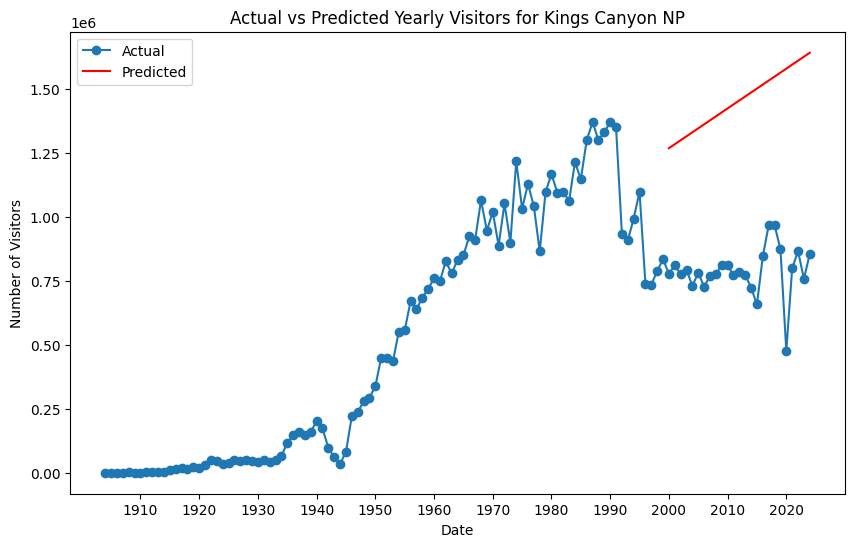

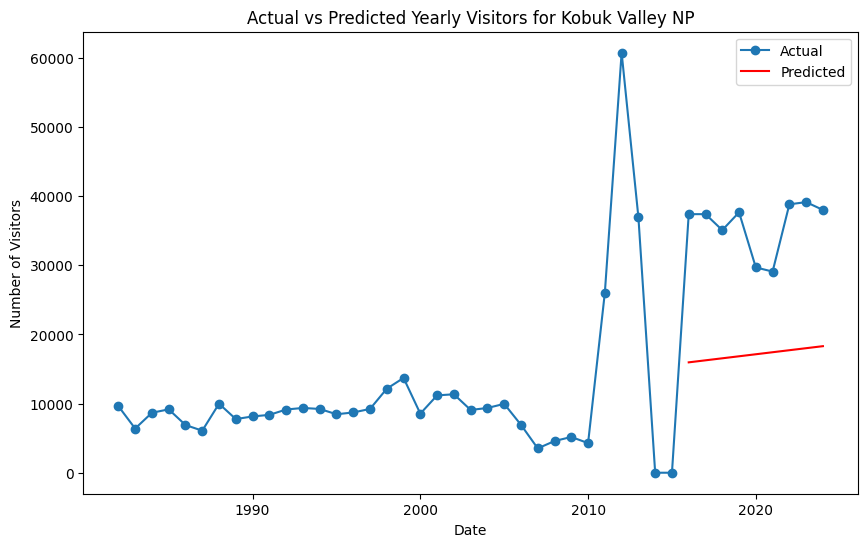

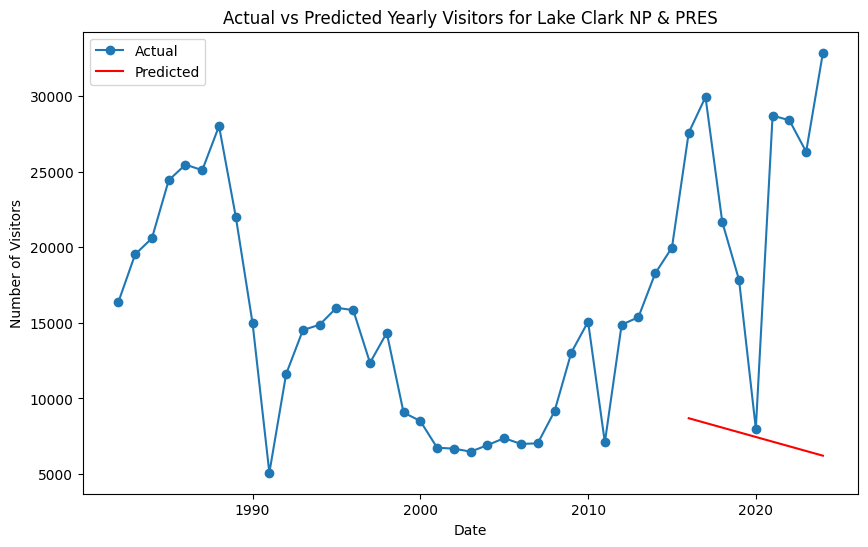

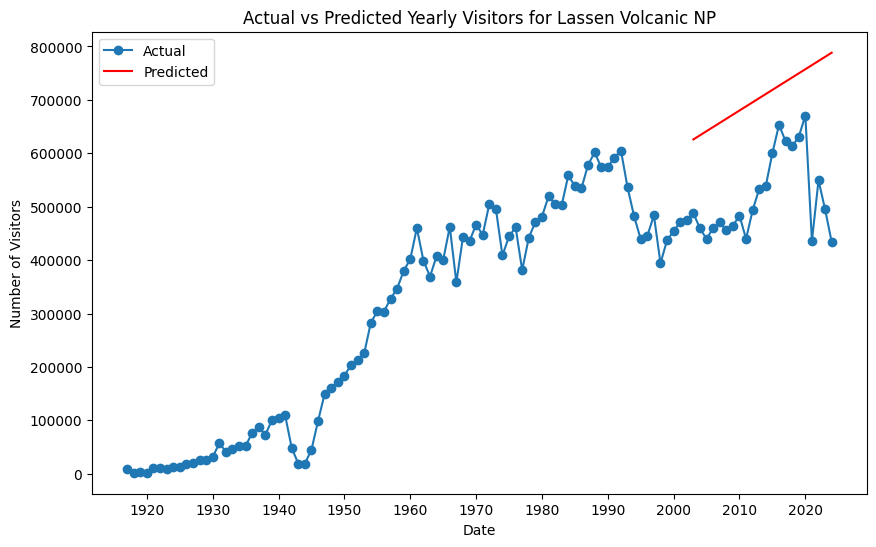

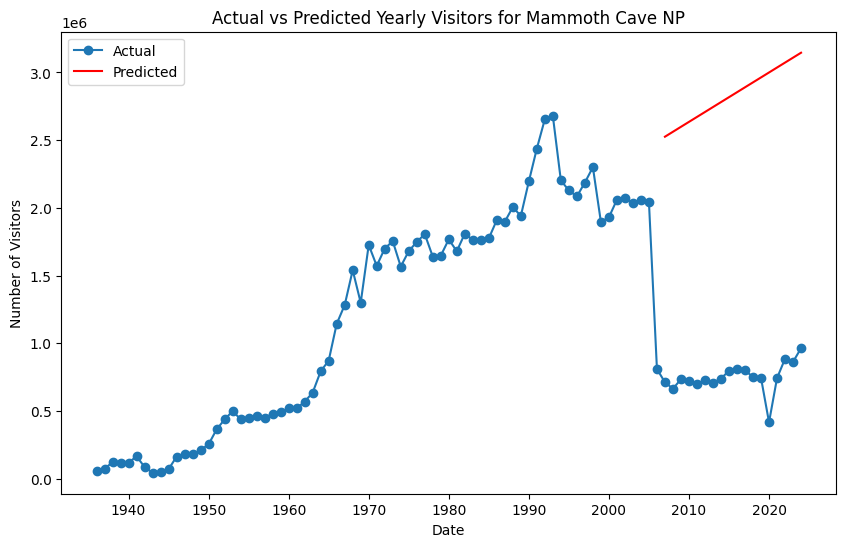

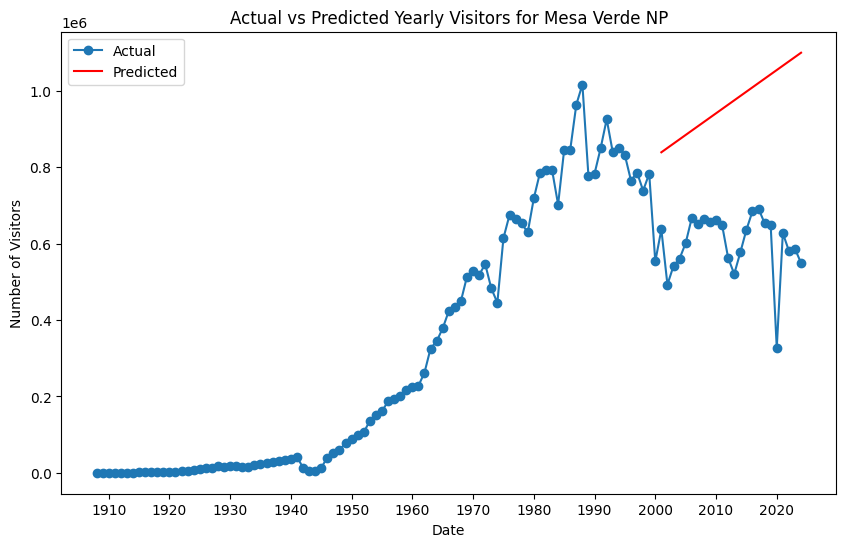

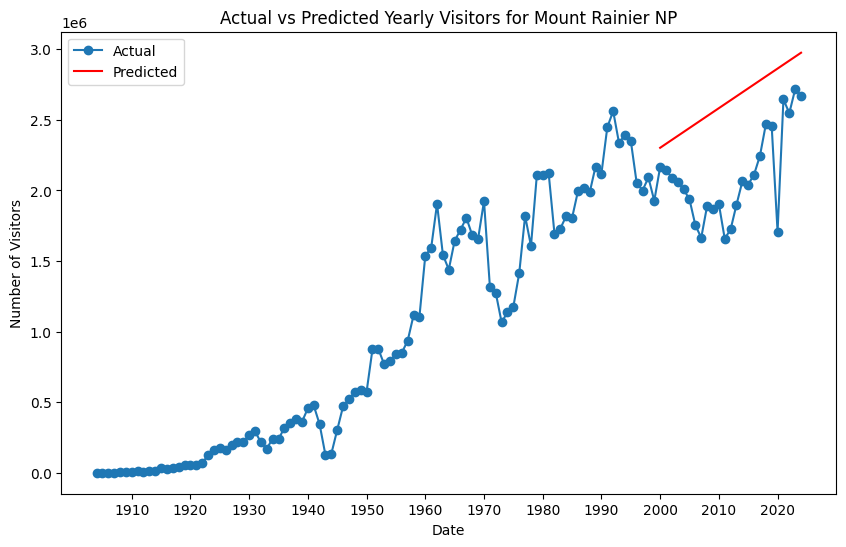

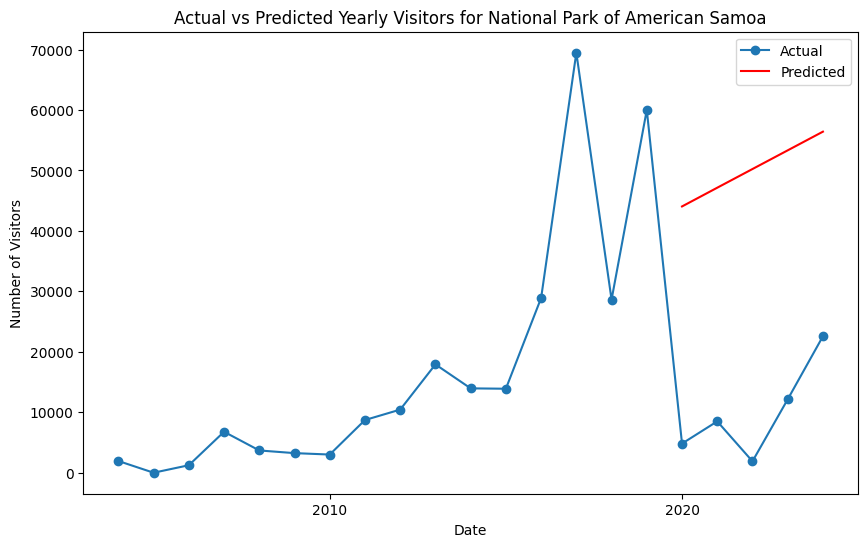

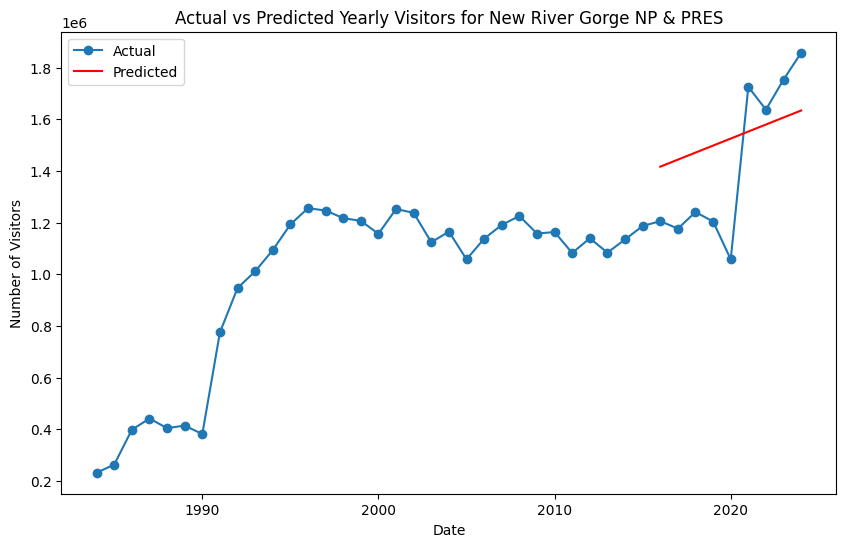

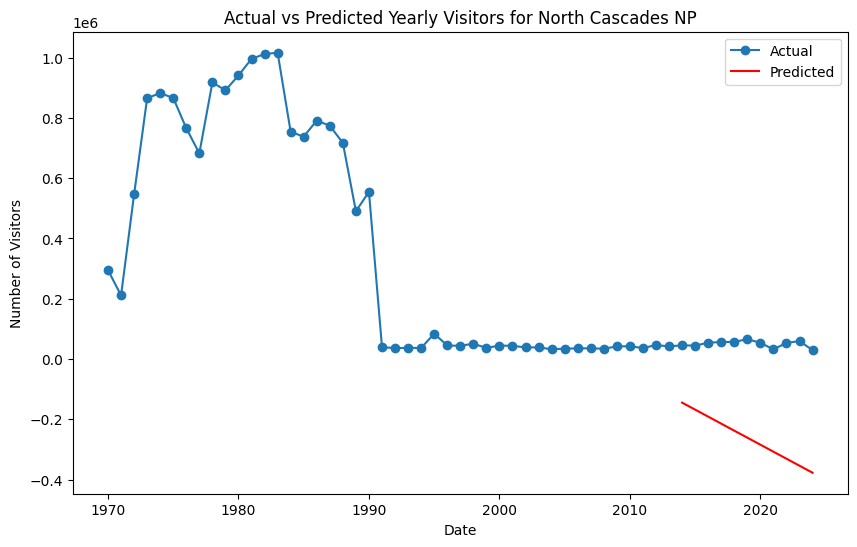

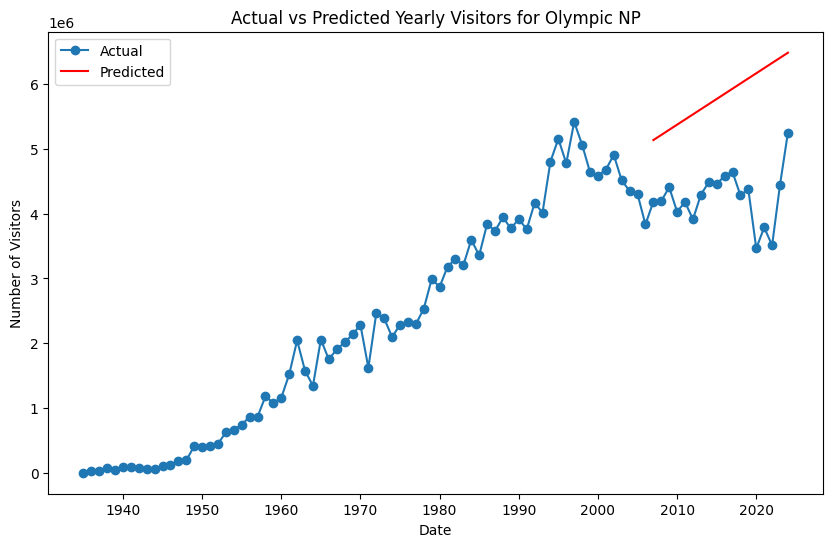

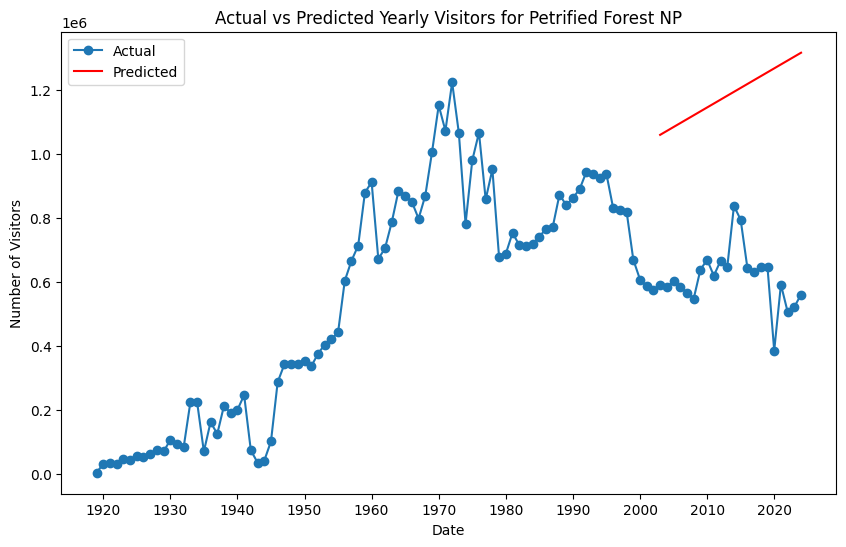

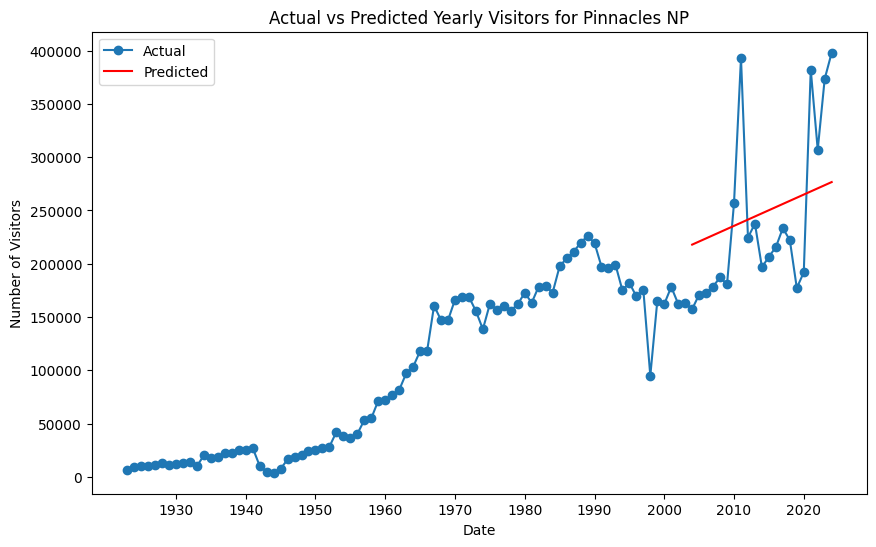

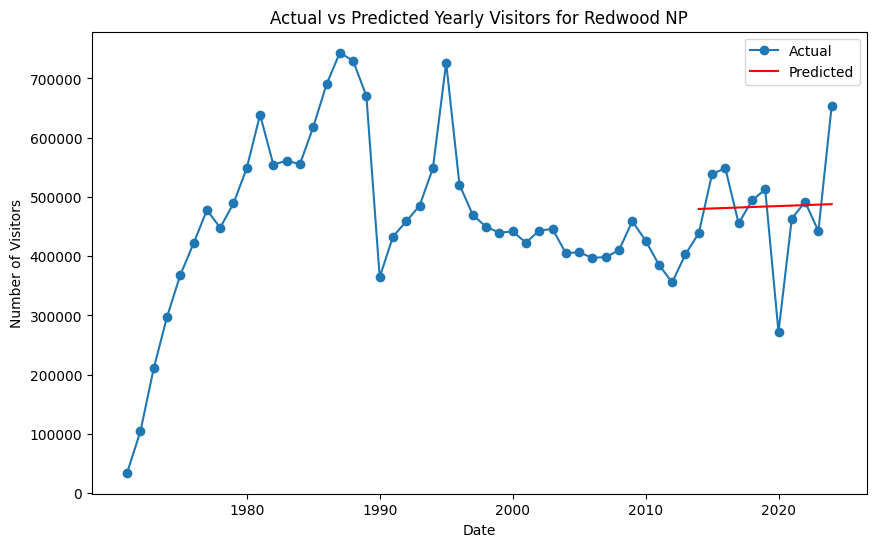

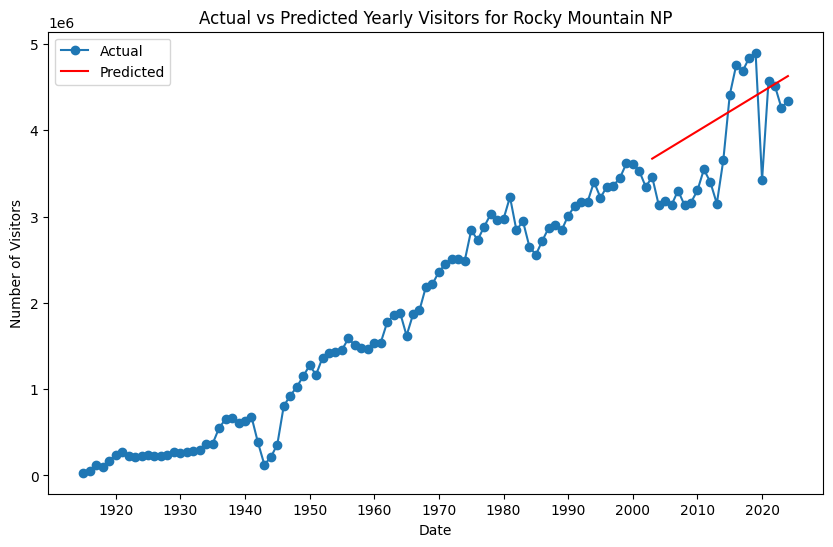

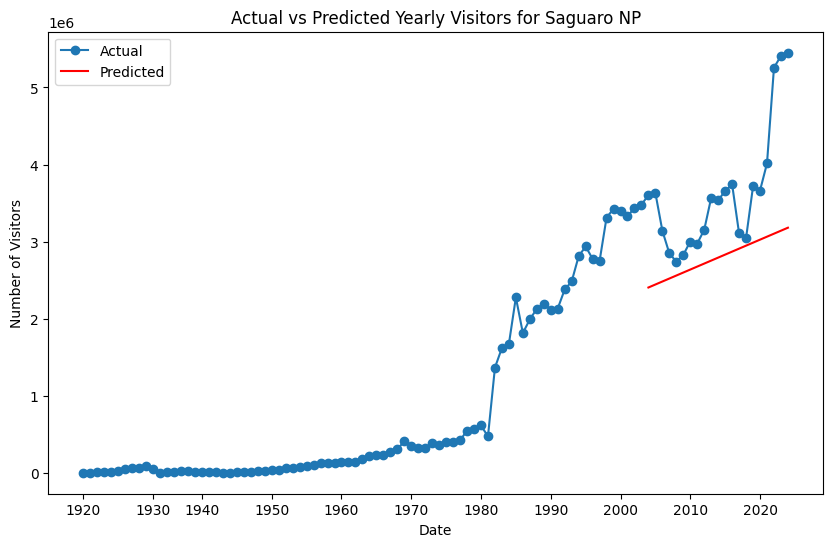

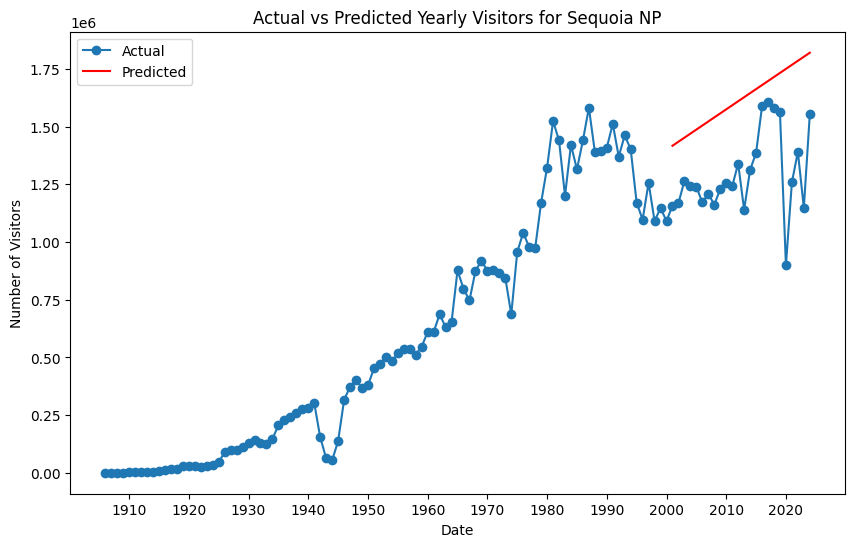

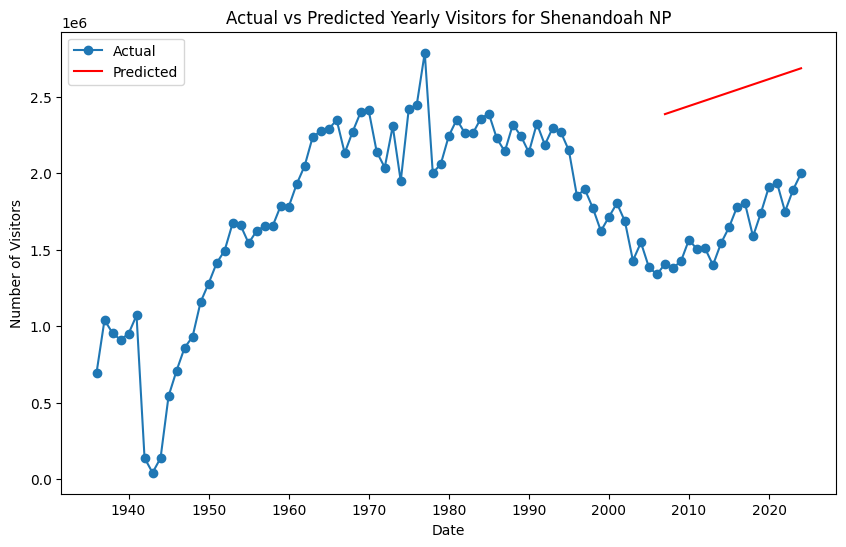

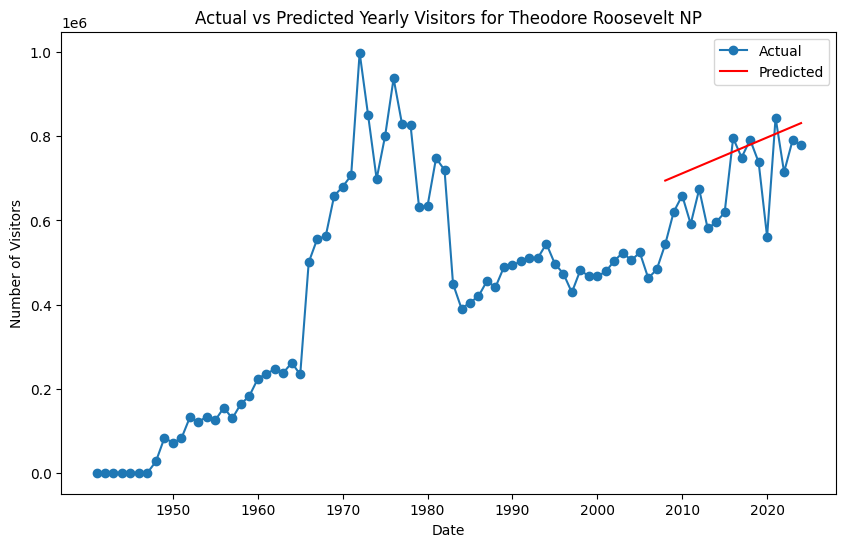

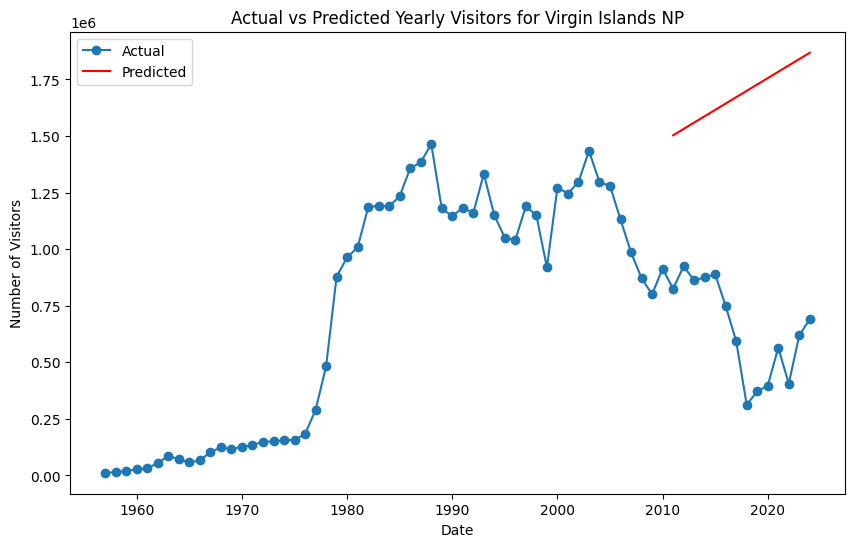

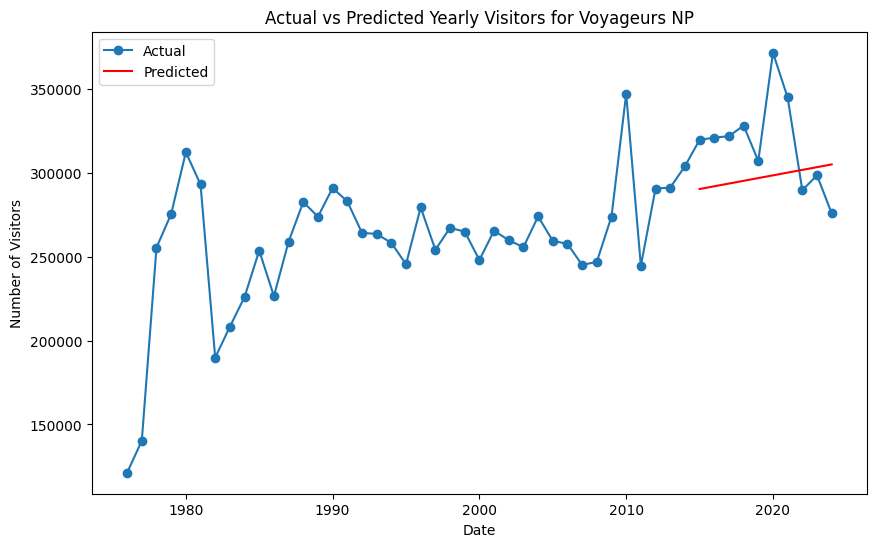

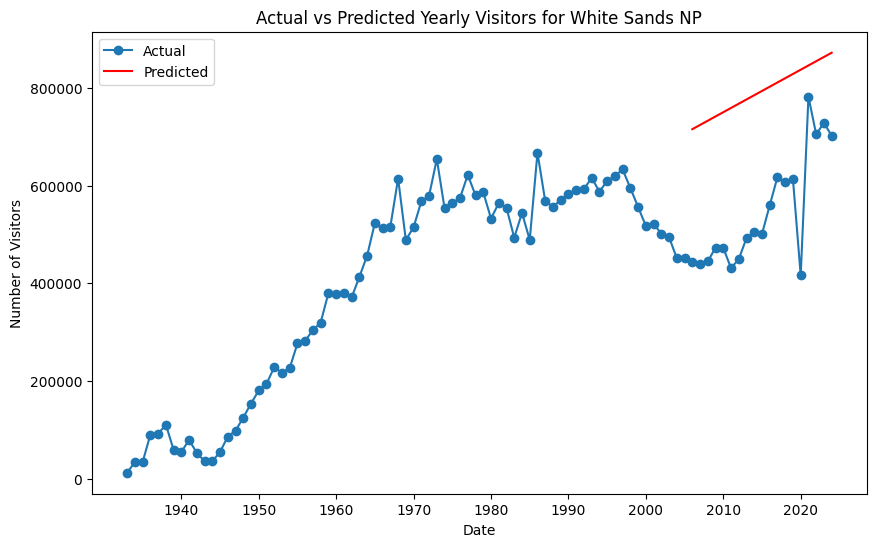

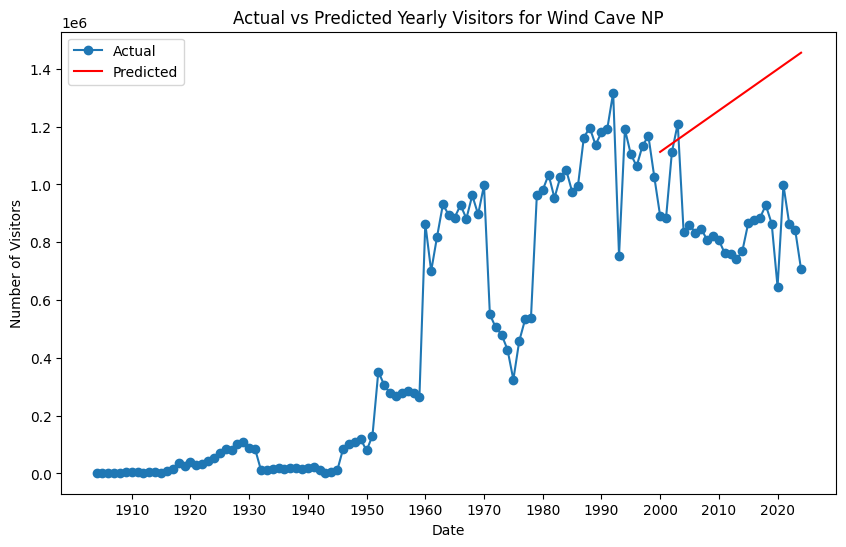

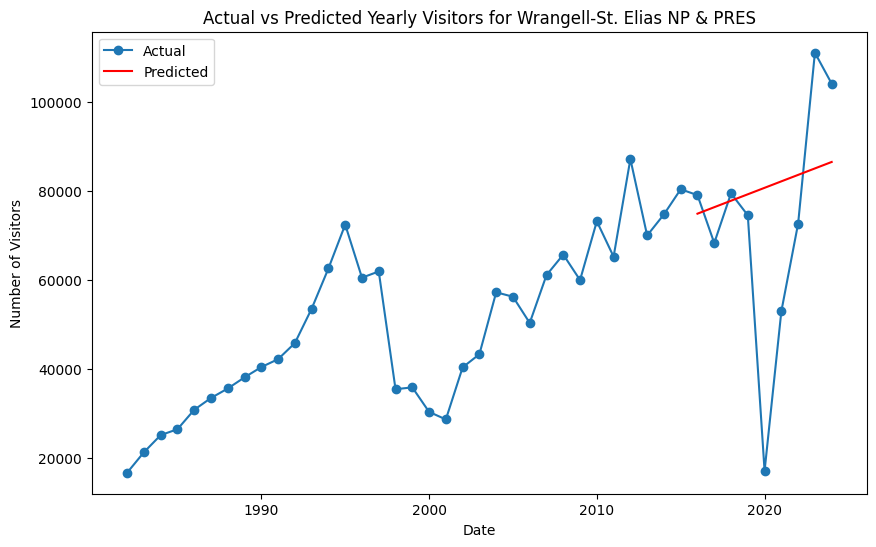

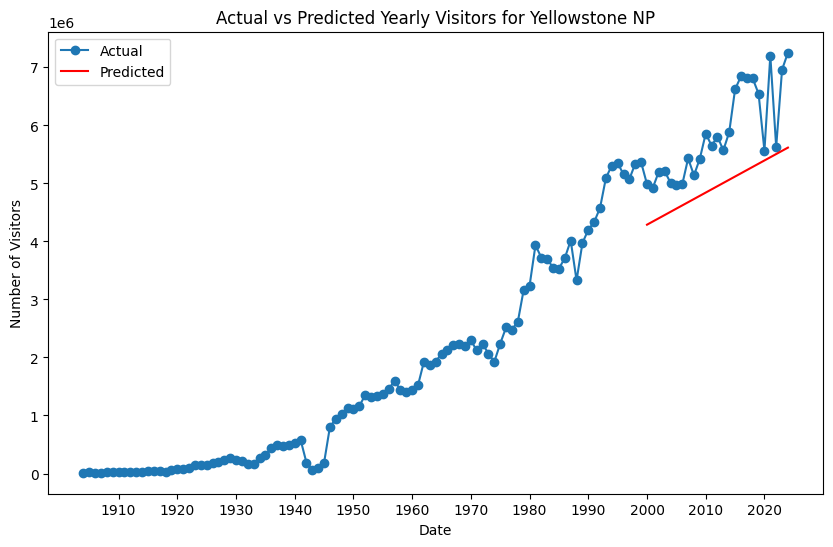

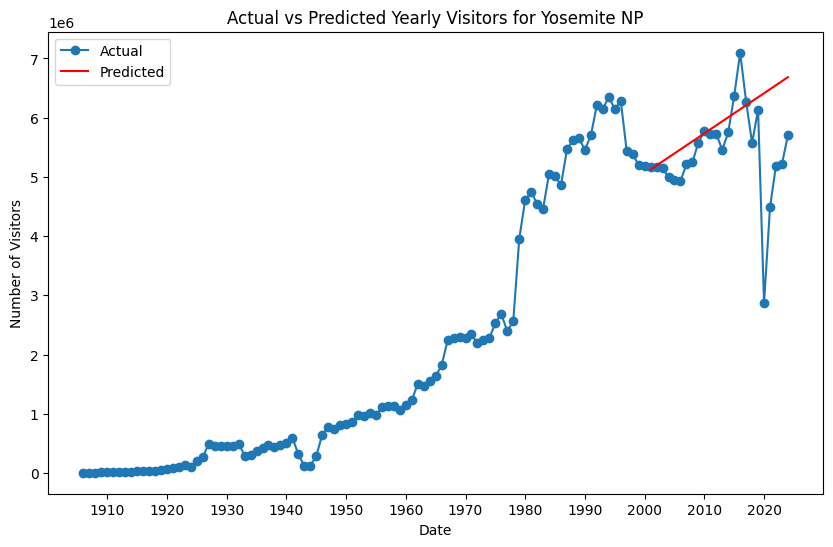

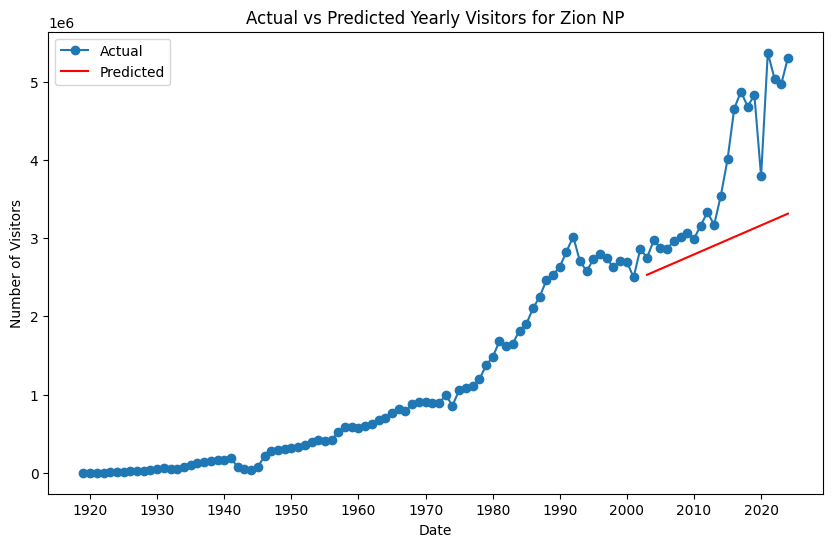

In [52]:
for park_name in park_list:
    park = df[df["ParkName"] == park_name].copy()
    park['MonthIndex'] = park['Date'].map(pd.Timestamp.toordinal)

    X = park[['MonthIndex']]
    y = park['Total']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    R2[park_name] = r2_score(y_test, y_pred)

    plt.figure(figsize=(10, 6))
    plt.plot(park.index, park['Total'], label='Actual', marker='o')
    plt.plot(X_test.index, y_pred, label='Predicted', color='red')
    plt.title(f'Actual vs Predicted Yearly Visitors for {park_name}')
    plt.xlabel('Date')
    plt.ylabel('Number of Visitors')
    years = park['Date'].dt.year
    ticks = park.index[years % 10 == 0]
    labels = years[years % 10 == 0]
    plt.xticks(ticks, labels)
    plt.legend()
    plt.savefig(park_name + '.png')
    # plt.show()

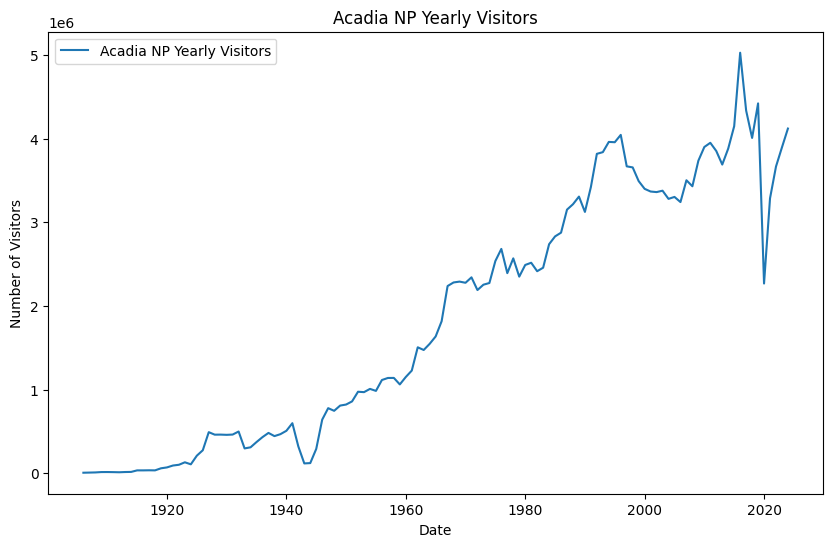

In [ ]:
# park = df[df["ParkName"] == park_name].copy()

# plt.figure(figsize=(10, 6))
# plt.plot(park['Date'], park['Total'], label='Acadia NP Yearly Visitors')
# plt.title('Acadia NP Yearly Visitors')
# plt.xlabel('Date')
# plt.ylabel('Number of Visitors')
# plt.legend()
# plt.show()

In [ ]:
# fig = px.line(x=park['Date'], y=park['Total'])
# fig.update_layout(title=f'{park_name} Yearly Visitors', xaxis_title='Date', yaxis_title='Number of Visitors')
# fig.show()

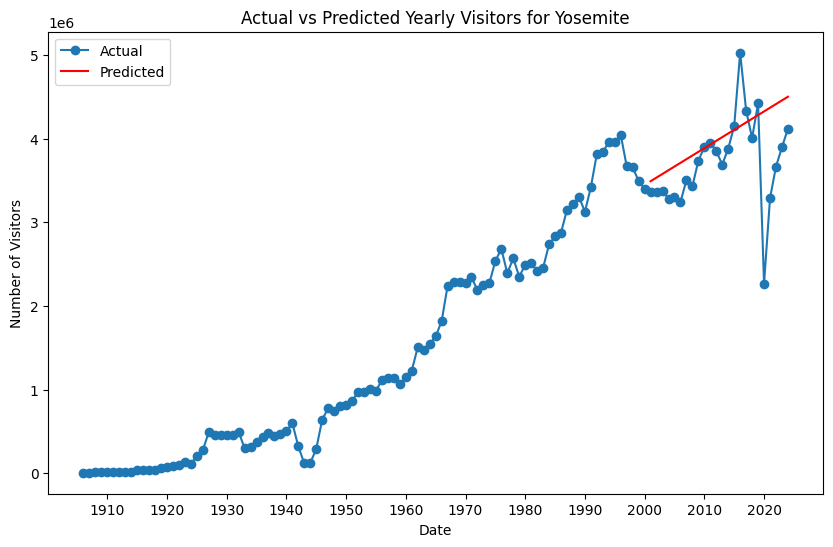

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.plot(park.index, park['Total'], label='Actual', marker='o')
# plt.plot(X_test.index, y_pred, label='Predicted', color='red')
# plt.title(f'Actual vs Predicted Yearly Visitors for {park_name}')
# plt.xlabel('Date')
# plt.ylabel('Number of Visitors')
# years = park['Date'].dt.year
# ticks = park.index[years % 10 == 0]
# labels = years[years % 10 == 0]
# plt.xticks(ticks, labels)
# plt.legend()
# plt.show()

In [ ]:
# fig = make_subplots()
# fig.add_trace(
#     go.Scatter(
#         x=park.index,
#         y=park['Total'],
#         mode='lines',
#         name='Actual'
#     )
# )
# fig.add_trace(
#     go.Scatter(
#         x=X_test.index,
#         y=y_pred,
#         mode='lines',
#         name='Predicted'
#     )
# )
# ticks = park.index[park.index % 20 == 0]
# labels = park.loc[ticks, 'Date'].dt.year

# fig.update_layout(
#     title=f'Actual vs Predicted Yearly Visitors for {park_name}',
#     xaxis_title='Date',
#     yaxis_title='Number of Visitors',
#     xaxis=dict(
#         tickmode='array',
#         tickvals=ticks,
#         ticktext=labels
#     ),
#     template='plotly_white'
# )

# fig.show()